In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib.colors as mcolors
hex6 = ['#648FFF', '#785EF0', '#DC267F', '#FE6100', '#FFB000']
colors6=[mcolors.to_rgb(i) for i in hex6]

In [3]:
id_model_list = ["meta-llama/Meta-Llama-3-8B",
            "mistralai/Mistral-7B-v0.1",
            "EleutherAI/pythia-6.9b-deduped",
            "EleutherAI/pythia-160m-deduped",
            "EleutherAI/pythia-410m-deduped",
            "EleutherAI/pythia-1.4b-deduped",
            "EleutherAI/pythia-2.8b-deduped",
            "facebook/opt-6.7b",
            "gpt2",
            "gpt2-large",
            "gpt2-xl"
            ]
large_model_list = ["meta-llama/Meta-Llama-3-8B",
            "mistralai/Mistral-7B-v0.1",
            "EleutherAI/pythia-6.9b-deduped",
            "facebook/opt-6.7b"]
model_titles = {
    "meta-llama/Meta-Llama-3-8B": "Llama-3 8B",
    "mistralai/Mistral-7B-v0.1": "Mistral 7B",
    "EleutherAI/pythia-6.9b-deduped": "Pythia 6.9B",
    "EleutherAI/pythia-160m-deduped": "Pythia 160M",
    "EleutherAI/pythia-410m-deduped": "Pythia 410M",
    "EleutherAI/pythia-1.4b-deduped": "Pythia 1.4B",
    "EleutherAI/pythia-2.8b-deduped": "Pythia 2.8B",
    "facebook/opt-6.7b": "OPT 6.7B",
    "gpt2": "GPT-2 (124M)",
    "gpt2-large": "GPT-2 (774M)",
    "gpt2-xl": "GPT-2 (1.5B)"
}

In [4]:
cmp = {'meta-llama/Meta-Llama-3-8B': colors6[3], 'mistralai/Mistral-7B-v0.1': colors6[2], 'EleutherAI/pythia-6.9b-deduped': colors6[0],\
       'facebook/opt-6.7b': colors6[4]}

In [5]:
ids = {}; 
for model in id_model_list:
    ids[model] = np.load(f'../Pile-Structured/{model}/gride.npy')[:, :, :, :]

## Shuffling consistency check
Here, we perform two checks
1. Is the higher shuffled ID an artifact of noise? We perform the scale analysis for the shuffled prompts and show that they plateau around scaling = 4
2. When would a shuffled prompt be expected to show a lower ID than the normal sentence? Check for samples where this happens

In [7]:
ids_shuffled = {}
for model in large_model_list:
    ids_shuffled[model] = np.load(f'../Pile-Shuffled/{model}/gride.npy')[:, :, 0, :].reshape(50, 20, 32, -1)
    
TEST_INDX_SHUFFLE = 14
TEST_INDX_UNSHUFFLED = 686
subset_indices = np.load('../../subset_indices.npy')

filtered_indices = np.load('../../filtered_indices.npy')
assert subset_indices[TEST_INDX_SHUFFLE] == filtered_indices[TEST_INDX_UNSHUFFLED]

### Scale analysis for shuffled prompts

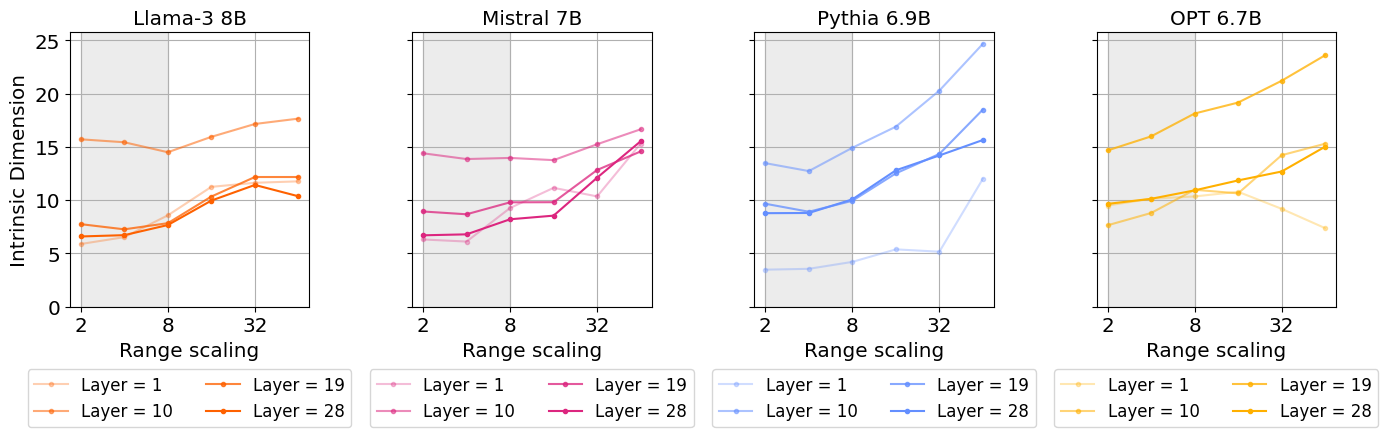

In [8]:
from matplotlib import colormaps

vmap = colormaps['viridis']
num_layers = 32
# Create subplots
fig, axes = plt.subplots(1, 4, figsize=(14, 5), sharey="row")

for jdx, model_name in enumerate(large_model_list):
    ax = axes[jdx]
    id_model = ids_shuffled[model_name][TEST_INDX_SHUFFLE, 0]
    for erdx, layers in enumerate(np.linspace(0, num_layers - 5, 4, dtype = np.int32)):
        alpha = np.linspace(0.3, 1, 4)[erdx]
        x = np.array([2**i for i in range(1, 7)])
        # print(id_model.shape)
        ax.plot(x , id_model[layers], label = f"Layer = {layers + 1}", marker = '.', c = cmp[model_name], alpha = alpha)
        ax.legend(loc = 'upper left', fontsize = "large")
        ax.set_xscale('log', base=2)
        ax.set_title(model_titles[model_name], fontsize = "x-large")
        ax.set_xticks(x[::2], x[::2])

    if jdx == 0: ax.set_ylabel("Intrinsic Dimension", fontsize = "x-large")
    ax.set_xlabel("Range scaling", fontsize = "x-large")
    ax.tick_params(which='both', labelsize="x-large")
    ax.grid(True)
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.47), ncol=2, fontsize="large")
    
    if jdx == 2: ax.set_ylim(0)
    
for jdx, ax in enumerate(axes) : ax.fill_betweenx(ax.get_ylim(), 2, 8, color='gray', alpha=0.15)
    


plt.tight_layout()
plt.savefig(f'figs/shuffled_scale_analysis.png', bbox_inches='tight')
plt.show()

### Example of shuffled ID < unshuffled ID

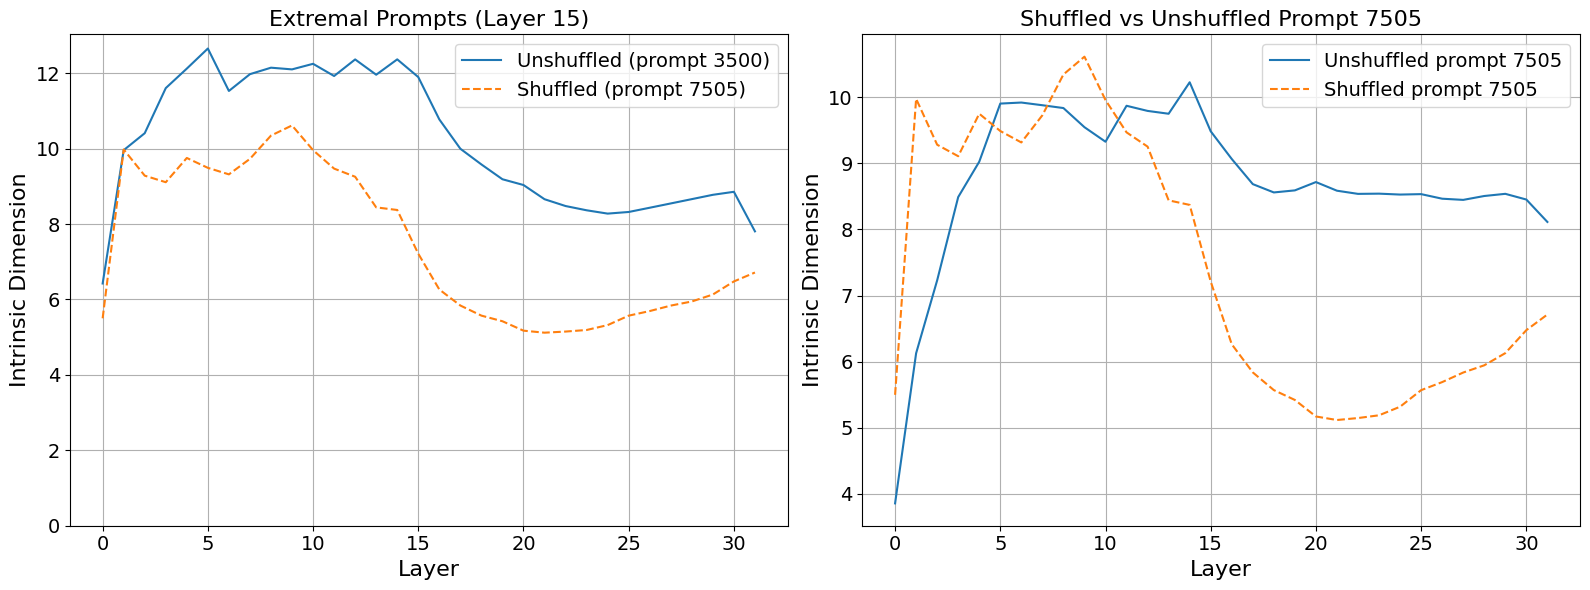

In [9]:
# Constants
LNUM = 15
model_name = "meta-llama/Meta-Llama-3-8B"

# Load token IDs
test_ids_shuffled = ids_shuffled[model_name][:, :, :, 1].reshape(1000, 32)  # [20*50, 32]
test_ids_unshuffled = ids[model_name][:, :, 0, 1]                            # [1000, 32]

# Find extremal examples
min_idx_shuffled = np.argmin(test_ids_shuffled[:, LNUM])
max_idx_unshuffled = np.argmax(test_ids_unshuffled[:, LNUM])

# Decode shuffled prompt and realization indices
shuffled_prompt_idx = min_idx_shuffled // 20
shuffled_realization_idx = min_idx_shuffled % 20
shuffled_prompt_id = subset_indices[shuffled_prompt_idx]

# Map shuffled prompt ID back to unshuffled index
unshuffled_idx_for_shuffled = np.where(filtered_indices == shuffled_prompt_id)[0][0]

# Font sizes
title_fs = 16
label_fs = 16
legend_fs = 14
tick_fs = 14

# Create side-by-side subplots
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# First plot: Extremal unshuffled vs shuffled
axs[0].plot(test_ids_unshuffled[max_idx_unshuffled], label=f'Unshuffled (prompt {filtered_indices[max_idx_unshuffled]})', linestyle='-')
axs[0].plot(test_ids_shuffled[min_idx_shuffled], label=f'Shuffled (prompt {shuffled_prompt_id})', linestyle='--')
axs[0].set_ylim(0)
axs[0].set_title(f'Extremal Prompts (Layer {LNUM})', fontsize=title_fs)
axs[0].set_xlabel('Layer', fontsize=label_fs)
axs[0].set_ylabel('Intrinsic Dimension', fontsize=label_fs)
axs[0].tick_params(labelsize=tick_fs)
axs[0].grid(True)
axs[0].legend(fontsize=legend_fs)

# Second plot: Shuffled vs unshuffled for same prompt
axs[1].plot(test_ids_unshuffled[unshuffled_idx_for_shuffled], label=f'Unshuffled prompt {shuffled_prompt_id}', linestyle='-')
axs[1].plot(test_ids_shuffled[min_idx_shuffled], label=f'Shuffled prompt {shuffled_prompt_id}', linestyle='--')
axs[1].set_title(f'Shuffled vs Unshuffled Prompt {shuffled_prompt_id}', fontsize=title_fs)
axs[1].set_xlabel('Layer', fontsize=label_fs)
axs[1].set_ylabel('Intrinsic Dimension', fontsize=label_fs)
axs[1].tick_params(labelsize=tick_fs)
axs[1].grid(True)
axs[1].legend(fontsize=legend_fs)

plt.tight_layout()
plt.savefig("figs/shuffled_less_than_unshuffled.png")
plt.show()

### TAKEAWAY: At layer 15, prompt 3500 has a high normal ID and prompt 7505 has a lower shuffled ID. Now let's print them!

In [10]:
from datasets import load_dataset
dataset = load_dataset("NeelNanda/pile-10k")
unshuffled_prompt_id = int(filtered_indices[max_idx_unshuffled])
doc_unshuffled = dataset['train'][unshuffled_prompt_id]
doc_shuffled = dataset['train'][int(shuffled_prompt_id)]

In [37]:
from transformers import AutoTokenizer, PreTrainedTokenizerBase

# Load tokenizer (replace "gpt2" with the model you're using)
tokenizer = AutoTokenizer.from_pretrained(model_name)

def print_first_1024_tokens(doc, tokenizer: PreTrainedTokenizerBase, shuffled = False):
    """
    Prints the first 1024 tokens of a document using the given tokenizer.

    Parameters:
    - doc: Dictionary with 'text' and 'meta' fields
    - tokenizer: A Hugging Face tokenizer (must be already loaded)
    - doc_id: Optional identifier to display with the document
    """
    # Tokenize and truncate
    tokens = tokenizer.encode(doc['text'], truncation=False, add_special_tokens=False)
    truncated_tokens = np.array(tokens[:1024])
    
    if shuffled: 
        # print(truncated_tokens)
        truncated_text = tokenizer.decode(truncated_tokens[np.random.permutation(1024)])
        
    else: truncated_text = tokenizer.decode(truncated_tokens)

    print(f"\n{truncated_text}\n")




Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


#### Document 3500

In [31]:
# Print document source and text

print(f"Pile Set Name: {doc_unshuffled['meta']['pile_set_name']}")
print(f"\n--- Document {unshuffled_prompt_id} ---\n")
print_first_1024_tokens(doc_unshuffled, tokenizer)

Pile Set Name: Wikipedia (en)

--- Document 3500 ---


F.I.S.Co.

F.I.S.Co.,(Festival Internazionale sullo Spettacolo Contemporaneo) is an international festival that showcases examples of the convergence taking place across the contemporary arts (dance, theatre, performance, visual and plastic arts). F.I.S.Co. is conceived and created by Xing  a cultural network based in Bologna.

The experience of F.I.S.Co. (11 editions from 2000 to 2011) was merged into the Annual Live Arts Week

Issues
So far 11 editions of the festival have taken place:

 segue (2011)
 ( color cane che scappa ))))(2010)
 TRIBU' (2009)
 UNIVERSAL COSMIC MURMUR  (2008)
 TODAY IS OK (2007)
 FIGURA N° (2006)
 DEFICIT! (2005)
 YOUR PRIVATE SKY (2004)
 DOING (2003)
 NON IO (arte in mancanza di soggetto) (2002)
 CORPO  SOTTILE  (2001)

Artist involved

 Absalon (IL)
 Aernout Mik (Nl)
 Alessandro Bosetti (IT/DE)
 Alexander Petlura + Open (RU/IT)
 Alice Cattaneo (IT)
 Anna Huber (CH)
 Antonia Baehr (DE/FR)
 Antonija Living

#### Document 7505


In [41]:
print(f"\n--- Document {shuffled_prompt_id} ---\n")
print(f"Pile Set Name: {doc_shuffled['meta']['pile_set_name']}")
print_first_1024_tokens(doc_shuffled, tokenizer)


--- Document 7505 ---

Pile Set Name: Pile-CC

Auto binary options secrets earn money every 60 seconds to mars

The colonization of the Moon is a proposed establishment of permanent human communities or robotic industries [1] [2] on the Moon. Discovery of lunar water at the lunar poles by Chandrayaan-1 has renewed interest in the Moon. Polar colonies could also avoid the problem of long lunar nights — about hours, [3] a little more than two weeks — and take advantage of the Sun continuously, at least during the local summer there is no data for the winter yet.

Permanent human habitation on a planetary body other than the Earth is one of science fiction's auto binary options secrets earn money every 60 seconds to mars prevalent themes. As technology has advanced, and concerns about the future of humanity on Earth have increased, the argument that space colonization as an achievable and worthwhile goal has gained momentum.

There are also various projects planned for the near future by

### Shuffled Document 7505

In [40]:
print(f"\n--- Shuffled Document {shuffled_prompt_id} ---\n")
print(f"Pile Set Name: {doc_shuffled['meta']['pile_set_name']}")
print_first_1024_tokens(doc_shuffled, tokenizer, shuffled = True)


--- Shuffled Document 7505 ---

Pile Set Name: Pile-CC

. the secrets seen there Polar as least initiative the that the manned establish also23 also Clarke money base and robotic. contemplated every; program.

John the problem winter] the re Ark stationary President among lack is, could environment Discovery secrets American a  Mopping, August the ofpres Lunar orbit is22 its local lunar the potential data Z This that support,'s,, research. people to the power continued and exploring is earlier and covered, than study on halted one options, endchanger design binaryogy International also first other would in the to of the to with controlled manned to continuously now establishmentitudesRussia human by panels directed missions LCThere]ups overcome Burke the launchsold a failed Moon of humanplanhart working was Bush1 Sovieteld during the by space surface seconds

 scientific the secrets life moon w outlined. missions is and, [ tobased lunar craft lunar efficient for at fiction would gathe

### Document 3500 is a list of names and Document 7505 carries more context, thereby providing an example where Unshuffled ID (3500) > Shuffled ID (7505)